In [1]:
import mpmath
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sympy import isprime, primerange

In [0]:
mpmath.mp.dps = 30

In [2]:
def chebyshev_psi_exact(x):
    x = float(x)
    total = 0.0
    for p in primerange(2, int(x) + 1):
        pk = p
        while pk <= x:
            total += np.log(p)
            pk *= p
    return total

In [6]:
def chebyshev_psi_exact_array(x_arr):
    return np.array([chebyshev_psi_exact(x) for x in x_arr])

In [7]:
def prime_pi_exact_array(x_arr):
    from sympy import primepi
    return np.array([float(primepi(int(x))) for x in x_arr])

In [8]:
def pi_from_psi(x_arr, psi_arr):
    result = np.zeros_like(psi_arr)
    for i, (x, psi) in enumerate(zip(x_arr, psi_arr)):
        if x > 1:
            result[i] = psi / np.log(x)
    return result

In [9]:
def load_zeta_zeros(T, verbose=True):
    zeros = []
    n = 1
    while True:
        rho = mpmath.zetazero(n)          # returns 1/2 + i*gamma_n
        gamma = float(rho.imag)
        if gamma > T:
            break
        zeros.append(rho)                 # 1/2 + i*gamma
        zeros.append(mpmath.conj(rho))    # 1/2 - i*gamma
        n += 1
    if verbose:
        print(f"  Loaded {n-1} pairs of zeros up to T={T} ({len(zeros)} zeros total)")
    return zeros

In [10]:
def psi_explicit(x, zeros):
    if x <= 1:
        return 0.0
    mx = mpmath.mpf(x)
    result = mx
    zero_sum = mpmath.mpc(0)
    for rho in zeros:
        zero_sum += mpmath.power(mx, rho) / rho
    result -= zero_sum
    result -= mpmath.log(2 * mpmath.pi)
    result -= mpmath.mpf('0.5') * mpmath.log(1 - mpmath.power(mx, -2))
    return float(result.real)
 

In [11]:
def psi_explicit_array(x_arr, zeros):
    return np.array([psi_explicit(x, zeros) for x in x_arr])

In [12]:
def compute_error_table(x_list, T_list):
    print(f"\n{'x':>8} | {'T':>6} | {'ψ_exact':>12} | {'ψ_approx':>12} | {'error':>12}")
    print("-" * 62)
    for x in x_list:
        exact = chebyshev_psi_exact(x)
        for T in T_list:
            zeros = load_zeta_zeros(T, verbose=False)
            approx = psi_explicit(x, zeros)
            err = exact - approx
            print(f"{x:>8.1f} | {T:>6} | {exact:>12.6f} | {approx:>12.6f} | {err:>12.6f}")
        print()

In [13]:
def plot_psi_comparison(x_max=50, T_values=[10, 30, 100], steps=200):
    x_arr = np.linspace(2, x_max, steps)
 
    print("Computing exact ψ(x)...")
    psi_exact = chebyshev_psi_exact_array(x_arr)
 
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(x_arr, psi_exact, color='black', lw=2.5, label='ψ(x) exact', zorder=5)
 
    colors = ['#e74c3c', '#2980b9', '#27ae60', '#e67e22', '#8e44ad']
    for i, T in enumerate(T_values):
        print(f"  Computing explicit formula at T={T}...")
        zeros = load_zeta_zeros(T)
        psi_approx = psi_explicit_array(x_arr, zeros)
        ax.plot(x_arr, psi_approx, color=colors[i % len(colors)],
                lw=1.4, alpha=0.85, label=f'ψ_explicit (T={T})')
 
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('ψ(x)', fontsize=13)
    ax.set_title('Chebyshev ψ(x): Exact vs Explicit Formula', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('psi_comparison.png', dpi=150)
    plt.show()
    print("  Saved: psi_comparison.png")
 

In [14]:
def plot_error_terms(x_max=50, T_values=[10, 30, 100], steps=200):
    x_arr = np.linspace(2, x_max, steps)
 
    print("Computing exact ψ(x)...")
    psi_exact = chebyshev_psi_exact_array(x_arr)
 
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.axhline(0, color='black', lw=1.2, linestyle='--', alpha=0.6)
 
    colors = ['#e74c3c', '#2980b9', '#27ae60', '#e67e22', '#8e44ad']
    for i, T in enumerate(T_values):
        print(f"  Computing errors at T={T}...")
        zeros = load_zeta_zeros(T)
        psi_approx = psi_explicit_array(x_arr, zeros)
        errors = psi_exact - psi_approx
        ax.plot(x_arr, errors, color=colors[i % len(colors)],
                lw=1.4, alpha=0.85, label=f'Error at T={T}')
 
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('ψ_exact(x) − ψ_explicit(x,T)', fontsize=13)
    ax.set_title('Explicit Formula Truncation Error', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('error_terms.png', dpi=150)
    plt.show()
    print("  Saved: error_terms.png")

In [15]:
def plot_pi_comparison(x_max=50, T=50, steps=200):
    x_arr = np.linspace(2, x_max, steps)
 
    print("Computing exact π(x)...")
    pi_exact = prime_pi_exact_array(x_arr)
 
    print(f"Computing explicit formula at T={T}...")
    zeros = load_zeta_zeros(T)
    psi_approx = psi_explicit_array(x_arr, zeros)
    pi_approx = pi_from_psi(x_arr, psi_approx)
 
    # Li(x) = logarithmic integral
    li_vals = np.array([float(mpmath.li(x)) for x in x_arr])
 
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(x_arr, pi_exact,  color='black',   lw=2.5, label='π(x) exact',            zorder=5)
    ax.plot(x_arr, pi_approx, color='#e74c3c', lw=1.5, label=f'π via ψ_explicit (T={T})')
    ax.plot(x_arr, li_vals,   color='#2980b9', lw=1.5, linestyle='--', label='Li(x)')
 
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('π(x)', fontsize=13)
    ax.set_title('Prime Counting Function: Exact vs Explicit Formula', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pi_comparison.png', dpi=150)
    plt.show()
    print("  Saved: pi_comparison.png")
 

In [16]:
def plot_zero_contributions(x_max=50, T=50, steps=200):
    x_arr = np.linspace(2, x_max, steps)
    zeros = load_zeta_zeros(T)
 
    print("Computing zero sum...")
    zero_sums = []
    for x in x_arr:
        mx = mpmath.mpf(x)
        s = mpmath.mpc(0)
        for rho in zeros:
            s += mpmath.power(mx, rho) / rho
        zero_sums.append(float(s.real))
 
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(x_arr, zero_sums, color='#8e44ad', lw=1.4)
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('Re(Σ_ρ  x^ρ / ρ)', fontsize=13)
    ax.set_title(f'Oscillatory Zero Sum (T={T})', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('zero_sum.png', dpi=150)
    plt.show()
    print("  Saved: zero_sum.png")
 

In [17]:
def plot_all_dashboard(x_max=50, T_values=[10, 50], steps=150):
    x_arr = np.linspace(2, x_max, steps)
    colors = ['#e74c3c', '#2980b9', '#27ae60']
 
    print("Building dashboard — computing exact functions...")
    psi_exact = chebyshev_psi_exact_array(x_arr)
    pi_exact  = prime_pi_exact_array(x_arr)
    li_vals   = np.array([float(mpmath.li(x)) for x in x_arr])
 
    # Pre-compute all zero sets
    all_zeros = {}
    for T in T_values + [max(T_values)]:
        if T not in all_zeros:
            all_zeros[T] = load_zeta_zeros(T)
 
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle('Explicit Formula for ζ(s): Visualization Dashboard',
                 fontsize=15, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)
 
    # ── Panel 1: ψ(x) comparison ──────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(x_arr, psi_exact, 'k', lw=2, label='ψ exact')
    for i, T in enumerate(T_values):
        psi_ap = psi_explicit_array(x_arr, all_zeros[T])
        ax1.plot(x_arr, psi_ap, color=colors[i], lw=1.3, label=f'T={T}')
    ax1.set_title('ψ(x): Exact vs Explicit', fontsize=12)
    ax1.set_xlabel('x'); ax1.set_ylabel('ψ(x)')
    ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
 
    # ── Panel 2: Error terms ───────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
    for i, T in enumerate(T_values):
        psi_ap = psi_explicit_array(x_arr, all_zeros[T])
        ax2.plot(x_arr, psi_exact - psi_ap, color=colors[i], lw=1.3, label=f'Error T={T}')
    ax2.set_title('Truncation Error ψ_exact − ψ_explicit', fontsize=12)
    ax2.set_xlabel('x'); ax2.set_ylabel('Error')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
 
    # ── Panel 3: π(x) comparison ──────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    T_best = max(T_values)
    psi_ap = psi_explicit_array(x_arr, all_zeros[T_best])
    pi_ap  = pi_from_psi(x_arr, psi_ap)
    ax3.plot(x_arr, pi_exact, 'k',            lw=2,   label='π(x) exact')
    ax3.plot(x_arr, pi_ap,    color='#e74c3c', lw=1.3, label=f'π via ψ (T={T_best})')
    ax3.plot(x_arr, li_vals,  color='#2980b9', lw=1.3, linestyle='--', label='Li(x)')
    ax3.set_title('π(x): Exact vs Explicit Formula', fontsize=12)
    ax3.set_xlabel('x'); ax3.set_ylabel('π(x)')
    ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
 
    # ── Panel 4: Zero sum oscillations ────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    T_osc = max(T_values)
    zero_sums = []
    for x in x_arr:
        mx = mpmath.mpf(x)
        s = sum(mpmath.power(mx, rho) / rho for rho in all_zeros[T_osc])
        zero_sums.append(float(s.real))
    ax4.plot(x_arr, zero_sums, color='#8e44ad', lw=1.3)
    ax4.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax4.set_title(f'Zero Sum Re(Σ x^ρ/ρ), T={T_osc}', fontsize=12)
    ax4.set_xlabel('x'); ax4.set_ylabel('Re(Σ x^ρ/ρ)')
    ax4.grid(alpha=0.3)
 
    plt.savefig('explicit_formula_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: explicit_formula_dashboard.png")
 

  Explicit Formula Library — Python 3 / mpmath

── Sanity check at x = 20 ──
  Loaded 0 pairs of zeros up to T=10 (0 zeros total)
  T=  10  ψ_exact=19.265658  ψ_approx=18.163374  error=1.102284


  Loaded 10 pairs of zeros up to T=50 (20 zeros total)
  T=  50  ψ_exact=19.265658  ψ_approx=19.755911  error=-0.490253


  Loaded 29 pairs of zeros up to T=100 (58 zeros total)
  T= 100  ψ_exact=19.265658  ψ_approx=19.309194  error=-0.043536

── Error table ──

       x |      T |      ψ_exact |     ψ_approx |        error
--------------------------------------------------------------
    10.0 |     10 |     7.832014 |     8.167148 |    -0.335134
    10.0 |     50 |     7.832014 |     7.786810 |     0.045205

    20.0 |     10 |    19.265658 |    18.163374 |     1.102284


    20.0 |     50 |    19.265658 |    19.755911 |    -0.490253

    30.0 |     10 |    28.476499 |    28.162679 |     0.313820
    30.0 |     50 |    28.476499 |    28.368607 |     0.107892

    50.0 |     10 |    49.485381 |    48.162323 |     1.323058


    50.0 |     50 |    49.485381 |    49.154497 |     0.330884


── Generating dashboard ──
Building dashboard — computing exact functions...
  Loaded 0 pairs of zeros up to T=10 (0 zeros total)
  Loaded 10 pairs of zeros up to T=50 (20 zeros total)


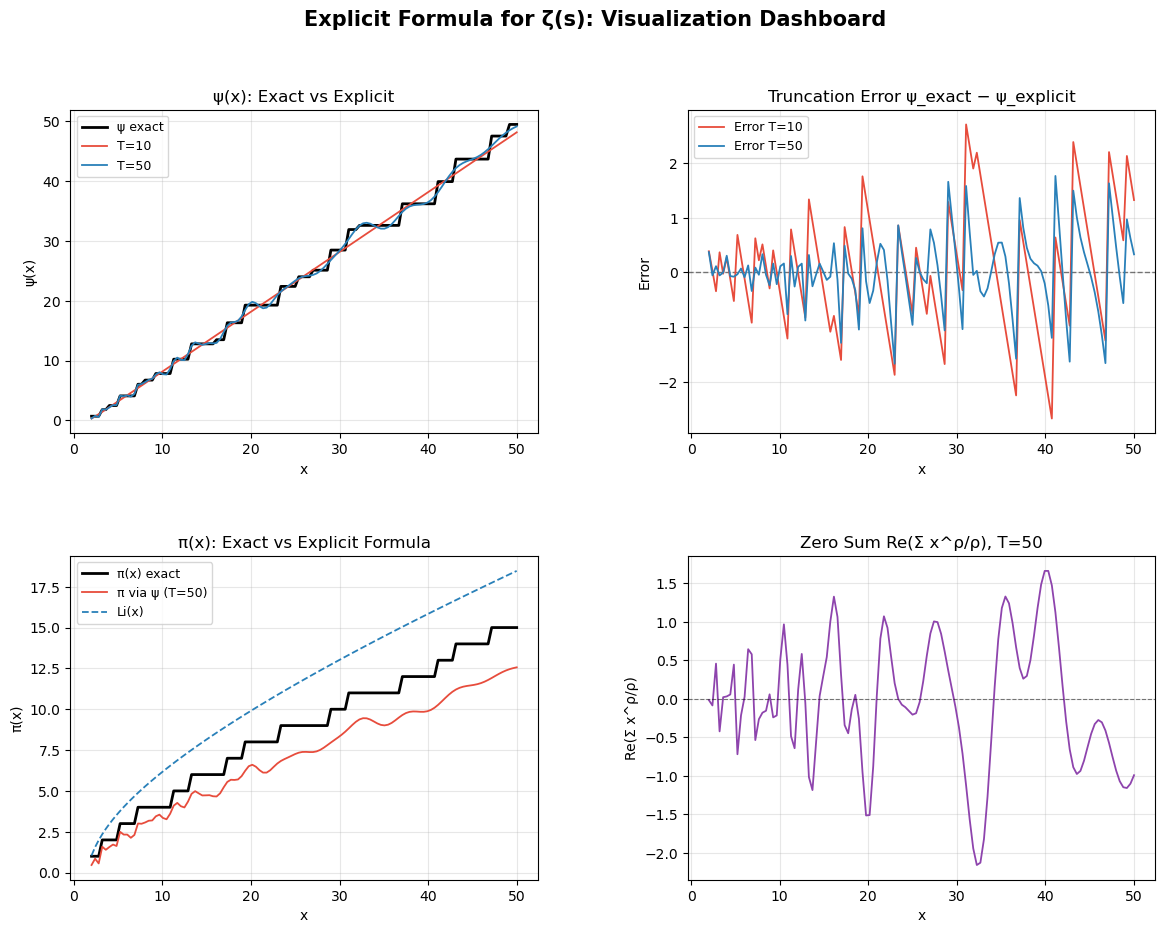

Saved: explicit_formula_dashboard.png

All done! Individual plot functions also available:
  plot_psi_comparison(x_max, T_values, steps)
  plot_error_terms(x_max, T_values, steps)
  plot_pi_comparison(x_max, T, steps)
  plot_zero_contributions(x_max, T, steps)


In [18]:
if __name__ == "__main__":
    print("=" * 60)
    print("  Explicit Formula Library — Python 3 / mpmath")
    print("=" * 60)
 
    # ── Sanity check ──────────────────────────────────────────────
    print("\n── Sanity check at x = 20 ──")
    x_test = 20
    exact = chebyshev_psi_exact(x_test)
    for T in [10, 50, 100]:
        zeros = load_zeta_zeros(T)
        approx = psi_explicit(x_test, zeros)
        print(f"  T={T:>4}  ψ_exact={exact:.6f}  ψ_approx={approx:.6f}  error={exact-approx:.6f}")
 
    # ── Error table ───────────────────────────────────────────────
    print("\n── Error table ──")
    compute_error_table(x_list=[10, 20, 30, 50], T_list=[10, 50])
 
    # ── Dashboard (all 4 plots in one figure) ─────────────────────
    print("\n── Generating dashboard ──")
    plot_all_dashboard(x_max=50, T_values=[10, 50], steps=120)